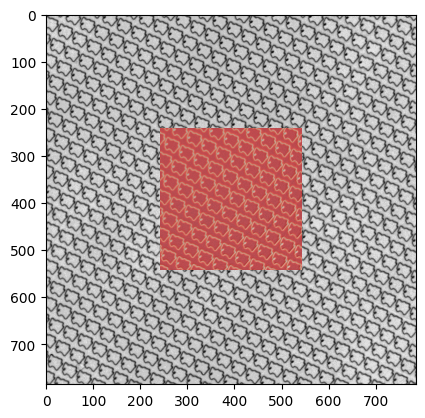

In [36]:
import numpy as np
from tifffile import imread
import matplotlib.pyplot as plt
from skimage.filters import sobel
from skimage.metrics import structural_similarity as ssim

BG = imread(r'..\raw FixedPattern 16x16 1462.tif')
img = (BG / 256).astype('uint8')
H, W = img.shape

plt.imshow(img, cmap='gray', extent=(0, W, H, 0))

img_cropped = imread(r'..\Chip_1462_1_real\obj0001_stainbackground_real.tiff')
h2, w2 = img_cropped.shape

xc, yc = W / 2, H / 2  # center in big-image coordinates

plt.imshow(
    img_cropped,
    cmap='Reds',
    alpha=0.7,
    extent=(
        xc - w2 / 2,
        xc + w2 / 2,
        yc + h2 / 2,
        yc - h2 / 2
    )
)

plt.xlim(0, W)
plt.ylim(H, 0)
plt.show()


Normalized Cross-Correlation: 0.9880  (99.4%)
SSIM: 0.0202  (2.0%)


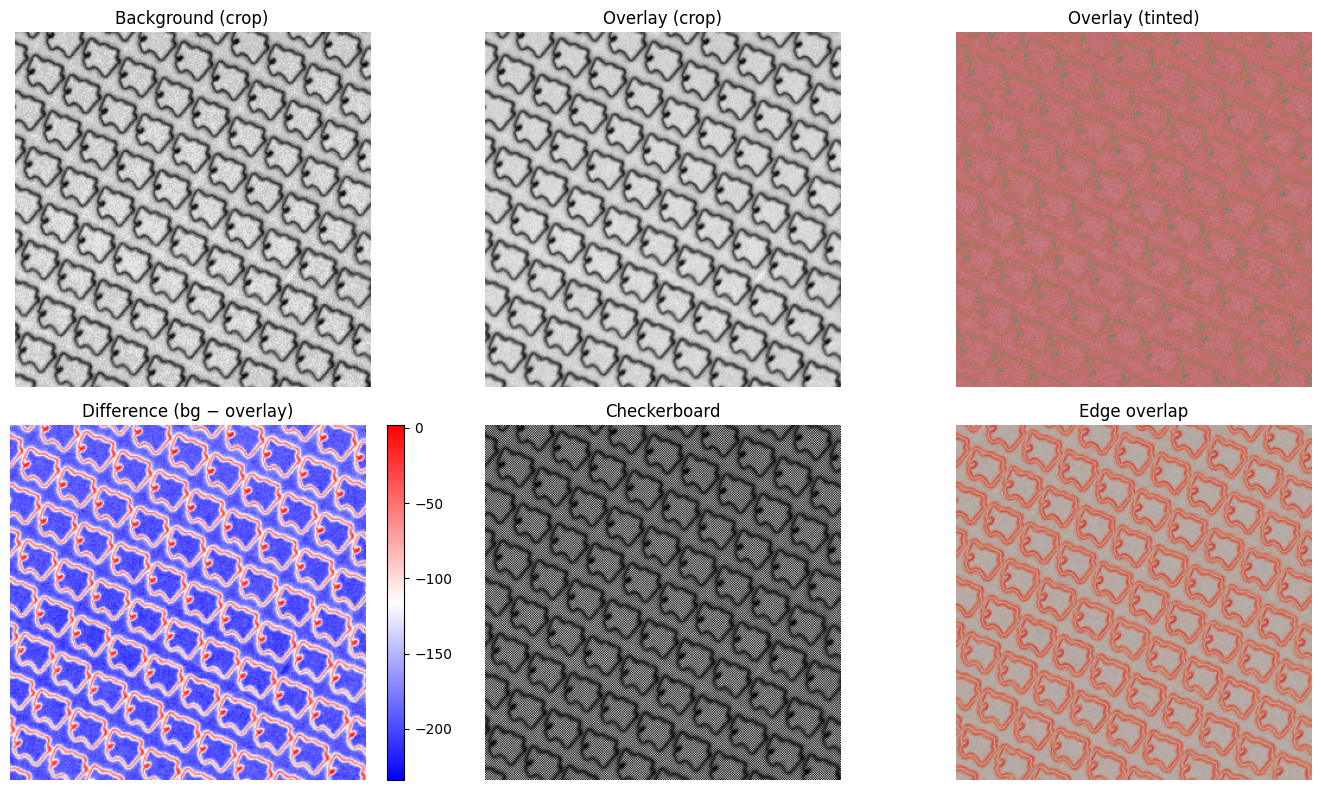

In [38]:
# Assume you placed img_cropped at (xc, yc) in big-image coords
x0 = int(xc - w2 / 2)
x1 = int(xc + w2 / 2)
y0 = int(yc - h2 / 2)
y1 = int(yc + h2 / 2)

bg_crop = img[y0:y1, x0:x1]
ov_crop = img_cropped[:bg_crop.shape[0], :bg_crop.shape[1]]

# Convert to float
bgf = bg_crop.astype(float)
ovf = ov_crop.astype(float)

# --------------------------------------------------
# 2. Numeric alignment metrics
# --------------------------------------------------

# Normalized Cross-Correlation (primary ranking metric)
bgf0 = bgf - bgf.mean()
ovf0 = ovf - ovf.mean()

ncc = np.sum(bgf0 * ovf0) / np.sqrt(np.sum(bgf0**2) * np.sum(ovf0**2))
ncc_percent = 100 * (ncc + 1) / 2

# Structural Similarity
ssim_score = ssim(bgf, ovf, data_range=np.ptp(ovf))
ssim_percent = 100 * ssim_score

print(f"Normalized Cross-Correlation: {ncc:.4f}  ({ncc_percent:.1f}%)")
print(f"SSIM: {ssim_score:.4f}  ({ssim_percent:.1f}%)")

# --------------------------------------------------
# 3. Visual diagnostics
# --------------------------------------------------

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

# Background crop
axes[0, 0].imshow(bgf, cmap='gray')
axes[0, 0].set_title("Background (crop)")
axes[0, 0].axis("off")

# Overlay crop
axes[0, 1].imshow(ovf, cmap='gray')
axes[0, 1].set_title("Overlay (crop)")
axes[0, 1].axis("off")

# Direct overlay
axes[0, 2].imshow(bgf, cmap='gray')
axes[0, 2].imshow(ovf, cmap='Reds', alpha=0.5)
axes[0, 2].set_title("Overlay (tinted)")
axes[0, 2].axis("off")

# Difference image
diff = bgf - ovf
im = axes[1, 0].imshow(diff, cmap='bwr')
axes[1, 0].set_title("Difference (bg − overlay)")
axes[1, 0].axis("off")
plt.colorbar(im, ax=axes[1, 0], fraction=0.046)

# Checkerboard
checker = bgf.copy()
mask = (np.indices(bgf.shape).sum(axis=0) % 2) == 0
checker[mask] = ovf[mask]
axes[1, 1].imshow(checker, cmap='gray')
axes[1, 1].set_title("Checkerboard")
axes[1, 1].axis("off")

# Edge alignment
edges_bg = sobel(bgf)
edges_ov = sobel(ovf)
axes[1, 2].imshow(edges_bg, cmap='gray')
axes[1, 2].imshow(edges_ov, cmap='Reds', alpha=0.7)
axes[1, 2].set_title("Edge overlap")
axes[1, 2].axis("off")

plt.tight_layout()
plt.show()